In [1]:
import numpy as np
import pandas as pd

# sklearn models
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# xgboost
from xgboost import XGBClassifier

c:\Users\HP\anaconda3\envs\ascend_env\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
c:\Users\HP\anaconda3\envs\ascend_env\lib\site-packages\xgboost\compat.py:106: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# 1 [EDA]

## 1.1 EDA Customer Data


=== MISSING SUMMARY TABLE ===
                  missing_count  missing_percent
Location                 184130            60.86
Age                      142470            47.09
LoyaltyTier               50412            16.66
CustomerID                    0             0.00
Gender                        0             0.00
RegistrationDate              0             0.00
WalletBalance                 0             0.00
year                          0             0.00
month                         0             0.00

=== AGE MISSING BY YEAR ===
       total  missing  missing_%
year                            
2016      20        2      10.00
2017      53        0       0.00
2018     304        7       2.30
2019    1127       32       2.84
2020    5603      528       9.42
2021    9787     1653      16.89
2022   28753     6714      23.35
2023  122723    34513      28.12
2024  134162    99021      73.81

=== LOCATION MISSING BY YEAR ===
       total  missing  missing_%
year                

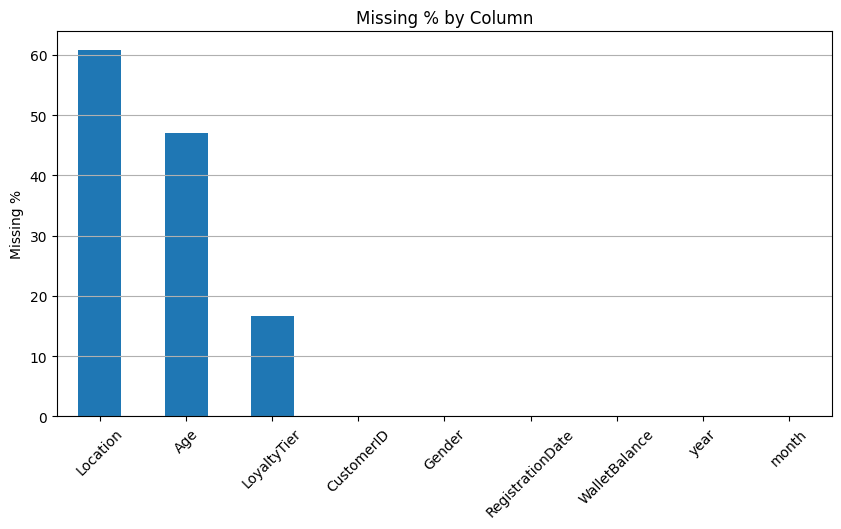

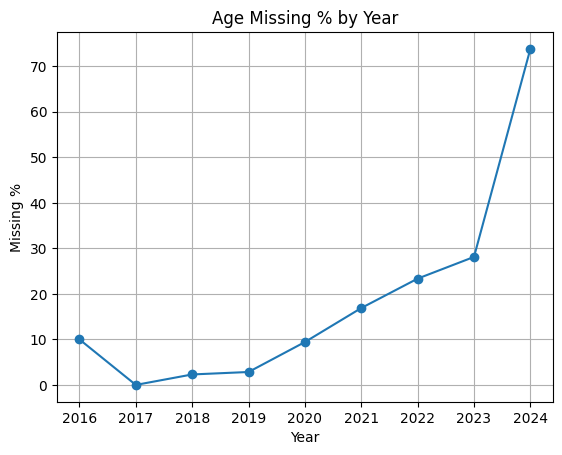

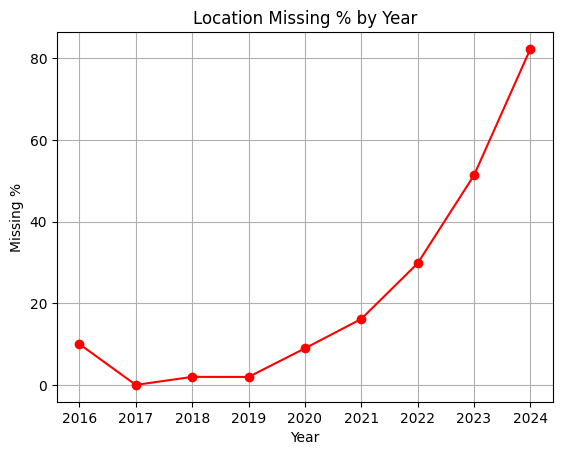

<Figure size 640x480 with 0 Axes>

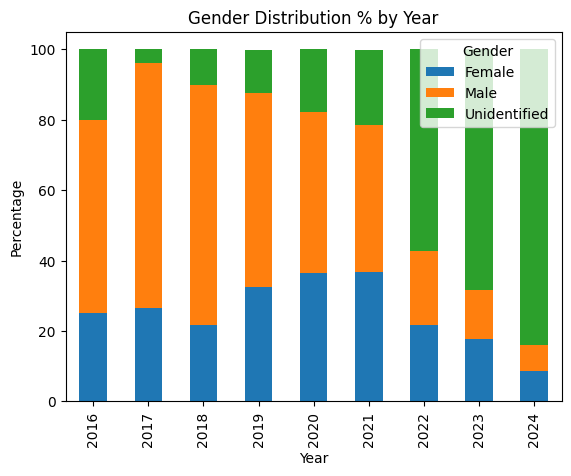

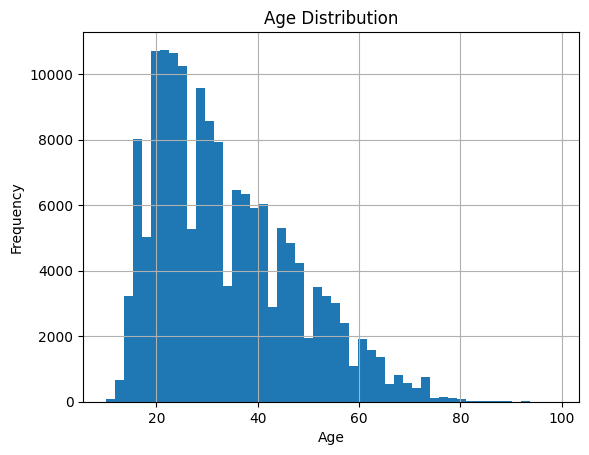


✅ DONE: TABLE + VISUAL COMPLETE


In [2]:
# =========================================================
# 0. IMPORT
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD DATA
# =========================================================
df_customer = pd.read_csv("customer_candidate_selection.csv")

# =========================================================
# 2. PREPROCESS
# =========================================================
df_customer['RegistrationDate'] = pd.to_datetime(
    df_customer['RegistrationDate'], errors='coerce'
)

df_customer['year'] = df_customer['RegistrationDate'].dt.year
df_customer['month'] = df_customer['RegistrationDate'].dt.month

df_customer['Age'] = pd.to_numeric(df_customer['Age'], errors='coerce')

df_customer['Gender'] = df_customer['Gender'].astype('string').str.strip()
df_customer['Location'] = df_customer['Location'].astype('string').str.strip()

# =========================================================
# 3. CLEAN AGE
# =========================================================
df = df_customer.copy()

df.loc[
    (df['Age'] <= 0) | (df['Age'] > 100),
    'Age'
] = pd.NA

# =========================================================
# 4. MISSING SUMMARY TABLE
# =========================================================
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_percent', ascending=False)

print("\n=== MISSING SUMMARY TABLE ===")
print(missing_summary)

# =========================================================
# 5. AGE MISSING BY YEAR (TABLE)
# =========================================================
age_missing_table = (
    df.groupby('year')['Age']
    .agg(
        total='size',
        missing=lambda x: x.isna().sum()
    )
)

age_missing_table['missing_%'] = (
    age_missing_table['missing'] / age_missing_table['total'] * 100
).round(2)

print("\n=== AGE MISSING BY YEAR ===")
print(age_missing_table)

# =========================================================
# 6. LOCATION MISSING BY YEAR (TABLE)
# =========================================================
location_missing_table = (
    df.groupby('year')['Location']
    .agg(
        total='size',
        missing=lambda x: x.isna().sum()
    )
)

location_missing_table['missing_%'] = (
    location_missing_table['missing'] / location_missing_table['total'] * 100
).round(2)

print("\n=== LOCATION MISSING BY YEAR ===")
print(location_missing_table)

# =========================================================
# 7. GENDER DISTRIBUTION BY YEAR (TABLE)
# =========================================================
gender_table = (
    df.groupby(['year', 'Gender'])
    .size()
    .unstack(fill_value=0)
)

gender_percent_table = (gender_table.div(
    gender_table.sum(axis=1), axis=0
) * 100).round(2)

print("\n=== GENDER COUNT BY YEAR ===")
print(gender_table)

print("\n=== GENDER % BY YEAR ===")
print(gender_percent_table)

# =========================================================
# 8. VISUAL: MISSING BAR
# =========================================================
plt.figure(figsize=(10,5))
missing_summary['missing_percent'].plot(kind='bar')
plt.title("Missing % by Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# =========================================================
# 9. VISUAL: AGE MISSING TREND
# =========================================================
plt.figure()
age_missing_table['missing_%'].plot(marker='o')
plt.title("Age Missing % by Year")
plt.xlabel("Year")
plt.ylabel("Missing %")
plt.grid()
plt.show()

# =========================================================
# 10. VISUAL: LOCATION MISSING TREND
# =========================================================
plt.figure()
location_missing_table['missing_%'].plot(marker='o', color='red')
plt.title("Location Missing % by Year")
plt.xlabel("Year")
plt.ylabel("Missing %")
plt.grid()
plt.show()

# =========================================================
# 11. VISUAL: GENDER STACKED
# =========================================================
plt.figure()
gender_percent_table.plot(kind='bar', stacked=True)
plt.title("Gender Distribution % by Year")
plt.ylabel("Percentage")
plt.xlabel("Year")
plt.show()

# =========================================================
# 12. HISTOGRAM (AGE)
# =========================================================
plt.figure()
df['Age'].dropna().hist(bins=50)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("\n✅ DONE: TABLE + VISUAL COMPLETE")

## 1.2 EDA Transaction Data


=== TRANSACTION MISSING SUMMARY ===


,missing_count,missing_percent
Location,107818,8.32
PaymentMethod,69015,5.32
TransactionID,0,0.00
CustomerID,0,0.00
Timestamp,0,0.00
TransactionType,0,0.00
Amount,0,0.00
Category,0,0.00
year,0,0.00
month,0,0.00



=== LOCATION MISSING BY YEAR ===


,total,missing,missing_%
year,,,
2024,1296549,107818,8.32



=== PAYMENT METHOD MISSING BY YEAR ===


...

Payment         730962
Transfer        547461
Bill Payment     18126
Name: TransactionType, dtype: int64


=== PAYMENT METHOD DISTRIBUTION (INCLUDE NaN) ===


E-WALLET        910473
DEBIT CARD      172007
CREDITCARD       74554
BANK ACCOUNT     70500
NaN              69015
Name: PaymentMethod, dtype: int64


=== PAYMENT METHOD % ===


E-WALLET        70.22
DEBIT CARD      13.27
CREDITCARD       5.75
BANK ACCOUNT     5.44
NaN              5.32
Name: PaymentMethod, dtype: float64

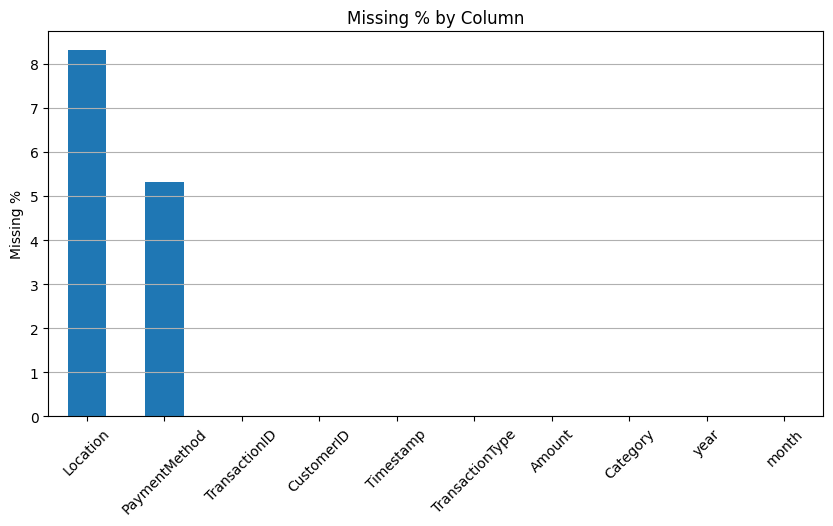

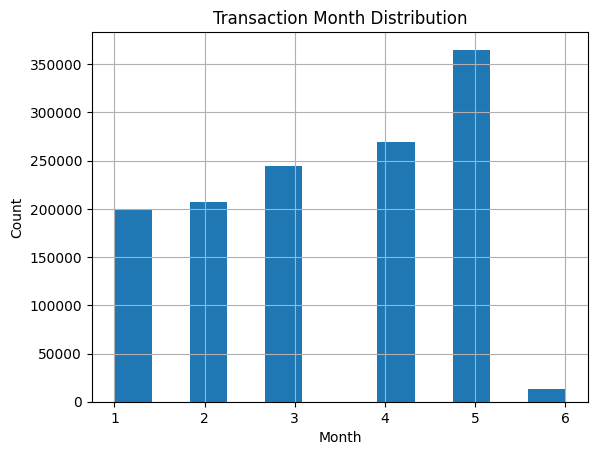

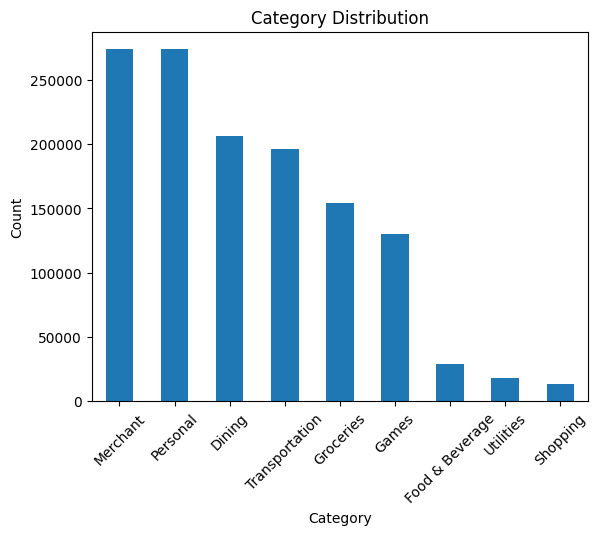

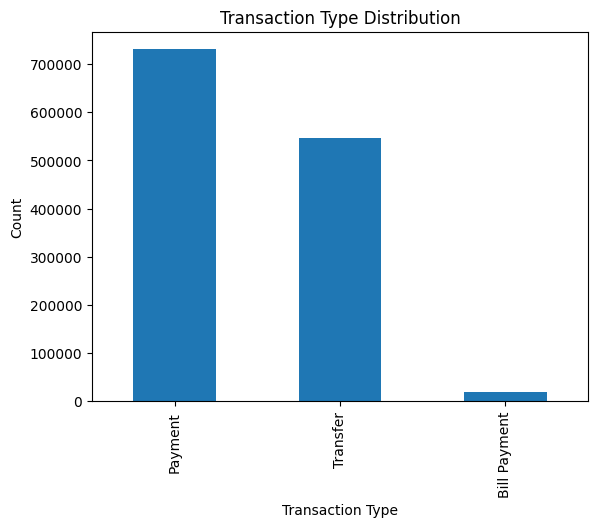

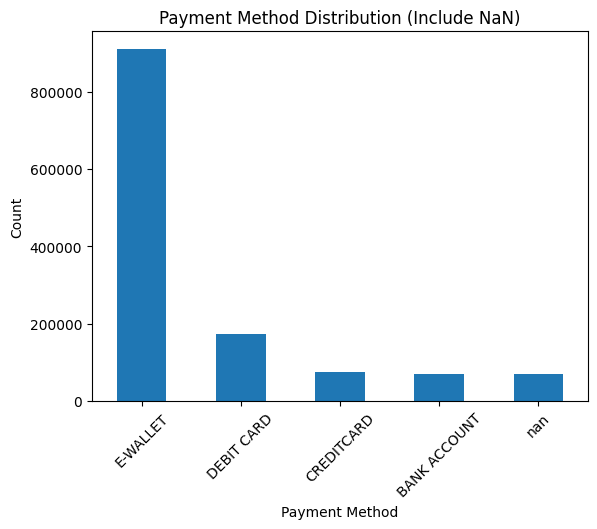

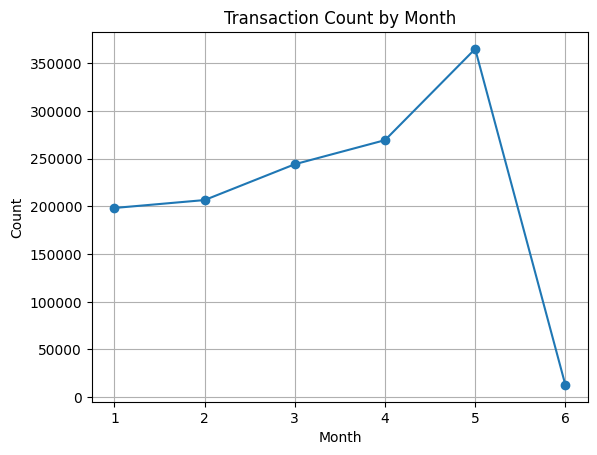


✅ DONE: FULL EDA (PRINT + VISUAL COMPLETE)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# 1. LOAD DATA
# =========================================================
df_transaction = pd.read_csv("transaction_candidate_selection.csv")

# =========================================================
# 2. PREPROCESS
# =========================================================
df_transaction['Timestamp'] = pd.to_datetime(
    df_transaction['Timestamp'], errors='coerce'
)

df_transaction['year'] = df_transaction['Timestamp'].dt.year
df_transaction['month'] = df_transaction['Timestamp'].dt.month

# =========================================================
# 3. SET DISPLAY OPTION (ไม่ truncate)
# =========================================================
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# =========================================================
# 4. MISSING SUMMARY
# =========================================================
missing_summary = pd.DataFrame({
    'missing_count': df_transaction.isna().sum(),
    'missing_percent': (df_transaction.isna().mean() * 100).round(2)
}).sort_values(by='missing_percent', ascending=False)

print("\n=== TRANSACTION MISSING SUMMARY ===")
display(missing_summary)

# =========================================================
# 5. LOCATION MISSING BY YEAR
# =========================================================
location_missing_year = (
    df_transaction.groupby('year')['Location']
    .agg(total='size', missing=lambda x: x.isna().sum())
)

location_missing_year['missing_%'] = (
    location_missing_year['missing'] / location_missing_year['total'] * 100
).round(2)

print("\n=== LOCATION MISSING BY YEAR ===")
display(location_missing_year)

# =========================================================
# 6. PAYMENT METHOD MISSING BY YEAR
# =========================================================
payment_missing_year = (
    df_transaction.groupby('year')['PaymentMethod']
    .agg(total='size', missing=lambda x: x.isna().sum())
)

payment_missing_year['missing_%'] = (
    payment_missing_year['missing'] / payment_missing_year['total'] * 100
).round(2)

print("\n=== PAYMENT METHOD MISSING BY YEAR ===")
display(payment_missing_year)

# =========================================================
# 7. TRANSACTION COUNT BY YEAR
# =========================================================
tx_count_year = df_transaction.groupby('year').size()

print("\n=== TRANSACTION COUNT BY YEAR ===")
display(tx_count_year)

# =========================================================
# 8. TRANSACTION COUNT BY MONTH
# =========================================================
tx_count_month = df_transaction.groupby('month').size()

print("\n=== TRANSACTION COUNT BY MONTH ===")
display(tx_count_month)

# =========================================================
# 9. CATEGORY DISTRIBUTION
# =========================================================
category_dist = df_transaction['Category'].value_counts()

print("\n=== CATEGORY DISTRIBUTION ===")
display(category_dist)

# =========================================================
# 10. TRANSACTION TYPE DISTRIBUTION
# =========================================================
tx_type_dist = df_transaction['TransactionType'].value_counts()

print("\n=== TRANSACTION TYPE DISTRIBUTION ===")
display(tx_type_dist)

# =========================================================
# 11. PAYMENT METHOD DISTRIBUTION (INCLUDE NaN)
# =========================================================
payment_dist = df_transaction['PaymentMethod'].value_counts(dropna=False)

print("\n=== PAYMENT METHOD DISTRIBUTION (INCLUDE NaN) ===")
display(payment_dist)

payment_percent = (
    df_transaction['PaymentMethod']
    .value_counts(dropna=False, normalize=True) * 100
).round(2)

print("\n=== PAYMENT METHOD % ===")
display(payment_percent)


# =========================================================
# ================= VISUAL PART ============================
# =========================================================

# =========================================================
# 12. MISSING BAR
# =========================================================
plt.figure(figsize=(10,5))
missing_summary['missing_percent'].plot(kind='bar')
plt.title("Missing % by Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# =========================================================
# 14. HISTOGRAM: MONTH
# =========================================================
plt.figure()
df_transaction['month'].hist(bins=12)
plt.title("Transaction Month Distribution")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# =========================================================
# 15. BAR: CATEGORY
# =========================================================
plt.figure()
category_dist.plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 16. BAR: TRANSACTION TYPE
# =========================================================
plt.figure()
tx_type_dist.plot(kind='bar')
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# =========================================================
# 17. BAR: PAYMENT METHOD (INCLUDE NaN)
# =========================================================
plt.figure()
payment_dist.plot(kind='bar')

plt.title("Payment Method Distribution (Include NaN)")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

# =========================================================
# 18. TIME TREND
# =========================================================
plt.figure()
tx_count_month.plot(marker='o')
plt.title("Transaction Count by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid()
plt.show()

# =========================================================
# DONE
# =========================================================
print("\n✅ DONE: FULL EDA (PRINT + VISUAL COMPLETE)")

### 1.2.1 Check Missing Location

In [4]:
# =========================================================
# 1. CREATE MISSING FLAG
# =========================================================
df = df_transaction.copy()

df['missing_location_flag'] = df['Location'].isna().astype(int)

# =========================================================
# 2. AGGREGATE PER CUSTOMER
# =========================================================
customer_missing = (
    df.groupby('CustomerID')
    .agg(
        total_tx=('TransactionID', 'count'),
        missing_location=('missing_location_flag', 'sum')
    )
    .reset_index()
)

# =========================================================
# 3. CALCULATE %
# =========================================================
customer_missing['missing_percent'] = (
    customer_missing['missing_location'] / customer_missing['total_tx'] * 100
)


# =========================================================
# 4. FILTER: PARTIAL MISSING ONLY
# =========================================================
partial_missing = customer_missing[
    (customer_missing['missing_location'] > 0) &
    (customer_missing['missing_location'] < customer_missing['total_tx'])
]

# =========================================================
# 5. SORT (เหมือนที่คุณโชว์)
# =========================================================
partial_missing = partial_missing.sort_values(
    by='missing_percent', ascending=False
)

# =========================================================
# 6. SHOW TOP 20
# =========================================================
print("\n=== CUSTOMERS WITH PARTIAL MISSING ===")
display(partial_missing.tail(20))

# =========================================================
# BASIC STATS
# =========================================================
print("\n=== MISSING PERCENT STATS ===")
display(customer_missing['missing_percent'].describe())

# =========================================================
# 1. CALCULATE MEAN
# =========================================================
mean_missing = customer_missing['missing_percent'].mean()

print(f"Mean missing_percent: {mean_missing:.2f}%")

# =========================================================
# 2. GET BAD CUSTOMER LIST
# =========================================================
bad_customer_ids = customer_missing[
    customer_missing['missing_percent'] > mean_missing
]['CustomerID']

print("\n=== BAD CUSTOMERS (above mean) ===")
display(bad_customer_ids.head())

# =========================================================
# 3. APPLY INVALID TO LOCATION FOR BAD CUSTOMERS IN TRANSACTION DATA
# =========================================================
df_transaction_updated = df_transaction.copy()

df_transaction_updated.loc[
    df_transaction_updated['CustomerID'].isin(bad_customer_ids),
    'Location'
] = 'invalid'

print("\n✅ DONE: Updated Location for bad customers")

print((df_transaction_updated['Location'] == 'invalid').any())
invalid_count = (df_transaction_updated['Location'] == 'invalid').sum()

print(f"Invalid count: {invalid_count}")


=== CUSTOMERS WITH PARTIAL MISSING ===


,CustomerID,total_tx,missing_location,missing_percent
52212,2573848,4,1,25.000000
37063,1779340,37,9,24.324324
49198,2403338,18,4,22.222222
42233,2036077,45,10,22.222222
46905,2279052,28,6,21.428571
59623,3080393,20,4,20.000000
20776,984874,5,1,20.000000
48875,2385028,5,1,20.000000
10612,504632,15,3,20.000000
36330,1745061,88,17,19.318182



=== MISSING PERCENT STATS ===


count    60180.000000
mean        25.832750
std         43.696178
min          0.000000
25%          0.000000
50%          0.000000
75%        100.000000
max        100.000000
Name: missing_percent, dtype: float64

Mean missing_percent: 25.83%

=== BAD CUSTOMERS (above mean) ===


4        207
274    14212
278    14556
370    18605
612    30823
Name: CustomerID, dtype: int64


✅ DONE: Updated Location for bad customers
True
Invalid count: 108458


# 2. [Clean Data and Merge Table]

In [5]:
# =========================================================
# 1. PREPARE CUSTOMER TABLE
# =========================================================
df_customer_clean = df_customer.copy()

# แปลงวันที่
df_customer_clean['RegistrationDate'] = pd.to_datetime(
    df_customer_clean['RegistrationDate'], errors='coerce'
)

# extract year / month
df_customer_clean['Registration_year'] = df_customer_clean['RegistrationDate'].dt.year
df_customer_clean['Registration_month'] = df_customer_clean['RegistrationDate'].dt.month

# keep only required columns
df_customer_clean = df_customer_clean[
    ['CustomerID', 'Registration_year', 'Registration_month']
]

print("\n=== CUSTOMER CLEAN ===")
display(df_customer_clean.head())


# =========================================================
# 2. CLEAN TRANSACTION (PaymentMethod)
# =========================================================
df_transaction_updated['PaymentMethod'] = df_transaction_updated['PaymentMethod'].fillna('Other')

print("\n=== PAYMENT METHOD AFTER CLEAN ===")
display(df_transaction_updated['PaymentMethod'].value_counts(dropna=False))


# =========================================================
# 3. MERGE (LEFT JOIN)
# =========================================================
df_merged = df_transaction_updated.merge(
    df_customer_clean,
    on='CustomerID',
    how='left'
)

print("\n=== MERGED DATA ===")
display(df_merged.head())


# =========================================================
# 4. VALIDATION
# =========================================================

# เช็ค missing หลัง merge
print("\n=== MISSING AFTER MERGE ===")
display(df_merged[['Registration_year', 'Registration_month']].isna().mean() * 100)

# เช็คจำนวน row ไม่เปลี่ยน
print("\nRows before merge:", len(df_transaction_updated))
print("Rows after merge :", len(df_merged))


=== CUSTOMER CLEAN ===


,CustomerID,Registration_year,Registration_month
0,3074082,2023,5
1,5545792,2023,11
2,6756636,2024,1
3,6835172,2024,1
4,4711710,2023,9



=== PAYMENT METHOD AFTER CLEAN ===


E-WALLET        910473
DEBIT CARD      172007
CREDITCARD       74554
BANK ACCOUNT     70500
Other            69015
Name: PaymentMethod, dtype: int64


=== MERGED DATA ===


,TransactionID,CustomerID,Timestamp,TransactionType,Amount,Category,PaymentMethod,Location,year,month,Registration_year,Registration_month
0,3836,1707873,2024-01-05 23:07:16+00:00,Payment,2.0,Games,E-WALLET,Online,2024,1,2022,12
1,549913,539132,2024-02-02 16:41:41+00:00,Payment,2.0,Dining,BANK ACCOUNT,BANGKOK,2024,2,2021,10
2,919618,138973,2024-03-27 21:37:08+00:00,Transfer,2.0,Merchant,E-WALLET,BANGKOK,2024,3,2020,8
3,563684,1197450,2024-02-04 18:29:11+00:00,Transfer,2.0,Merchant,E-WALLET,BANGKOK,2024,2,2022,9
4,550056,1251954,2024-02-02 17:06:47+00:00,Transfer,2.0,Merchant,E-WALLET,CHIANG MAI,2024,2,2022,9



=== MISSING AFTER MERGE ===


Registration_year     0.0
Registration_month    0.0
dtype: float64


Rows before merge: 1296549
Rows after merge : 1296549


In [6]:
region_map = {
    # ===== NORTH =====
    'CHIANG MAI': 'North',
    'CHIANG RAI': 'North',
    'LAMPANG': 'North',
    'LAMPHUN': 'North',
    'PHAYAO': 'North',
    'PHRAE': 'North',
    'NAN': 'North',
    'UTTARADIT': 'North',

    # ===== LOWER NORTH =====
    'PHITSANULOK': 'Lower North',
    'NAKHON SAWAN': 'Lower North',
    'PHETCHABUN': 'Lower North',
    'KAMPHAENG PHET': 'Lower North',
    'PHICHIT': 'Lower North',
    'SUKHOTHAI': 'Lower North',
    'UTHAI THANI': 'Lower North',
    'TAK': 'Lower North',

    # ===== NORTHEAST =====
    'KHON KAEN': 'Northeast',
    'UDON THANI': 'Northeast',
    'NAKHON RATCHASIMA': 'Northeast',
    'UBON RATCHATHANI': 'Northeast',
    'ROI ET': 'Northeast',
    'SAKON NAKHON': 'Northeast',
    'BURIRAM': 'Northeast',
    'SURIN': 'Northeast',
    'SISAKET': 'Northeast',
    'MAHA SARAKHAM': 'Northeast',
    'KALASIN': 'Northeast',
    'MUKDAHAN': 'Northeast',
    'NAKHON PHANOM': 'Northeast',
    'NONG BUA LAMPHU': 'Northeast',
    'NONG KHAI': 'Northeast',
    'LOEI': 'Northeast',
    'AMNAT CHAROEN': 'Northeast',
    'YASOTHON': 'Northeast',
    'CHAIYAPHUM': 'Northeast',
    'BUENG KAN': 'Northeast',

    # ===== CENTRAL =====
    'BANGKOK': 'Central',
    'NONTHABURI': 'Central',
    'PATHUM THANI': 'Central',
    'SAMUT PRAKAN': 'Central',
    'NAKHON PATHOM': 'Central',
    'SAMUT SAKHON': 'Central',
    'SAMUT SONGKHRAM': 'Central',
    'PHRA NAKHON SI AYUTTHAYA': 'Central',
    'SARABURI': 'Central',
    'LOPBURI': 'Central',
    'SUPHAN BURI': 'Central',
    'ANG THONG': 'Central',
    'SING BURI': 'Central',
    'CHAINAT': 'Central',
    'NAKHON NAYOK': 'Central',

    # ===== EAST =====
    'CHONBURI': 'East',
    'RAYONG': 'East',
    'CHANTHABURI': 'East',
    'TRAT': 'East',
    'CHACHOENGSAO': 'East',
    'PRACHINBURI': 'East',
    'SA KAEO': 'East',

    # ===== WEST =====
    'KANCHANABURI': 'West',
    'RATCHABURI': 'West',
    'PHETCHABURI': 'West',
    'PRACHUAP KHIRI KHAN': 'West',

    # ===== SOUTH =====
    'PHUKET': 'South',
    'KRABI': 'South',
    'SURAT THANI': 'South',
    'SONGKHLA': 'South',
    'TRANG': 'South',
    'SATUN': 'South',
    'CHUMPHON': 'South',
    'NAKHON SI THAMMARAT': 'South',
    'PHANG NGA': 'South',
    'RANONG': 'South',
    'PHATTHALUNG': 'South',
    'YALA': 'South',
    'PATTANI': 'South',
    'NARATHIWAT': 'South'
}

# =========================================================
# 1. NORMALIZE LOCATION (สำคัญที่สุด)
# =========================================================
df_merged['Location_clean'] = (
    df_merged['Location']
    .astype(str)
    .str.strip()
    .str.upper()
)

# =========================================================
# 2. MAP REGION (ตรง ๆ ไปเลย)
# =========================================================
df_merged['Region'] = df_merged['Location_clean'].map(region_map)

# =========================================================
# 3. HANDLE ONLINE (ต้องมี)
# =========================================================
df_merged.loc[
    df_merged['Location_clean'].str.contains('ONLINE', na=False),
    'Region'
] = 'Online'

# =========================================================
# 4. HANDLE INVALID (ห้ามแตะ)
# =========================================================
df_merged.loc[
    df_merged['Location_clean'] == 'INVALID',
    'Region'
] = 'invalid'

# =========================================================
# 5. HANDLE UNKNOWN (สุดท้าย)
# =========================================================
df_merged['Region'] = df_merged['Region'].fillna('Unknown')

print("\n=== REGION DISTRIBUTION ===")
display(df_merged['Region'].value_counts())


=== REGION DISTRIBUTION ===


Central        779796
Online         143513
Lower North    141260
invalid        108458
Northeast       52145
South           41883
North           15110
East            12373
West             2011
Name: Region, dtype: int64

In [ ]:
display(df_merged.head(3))
df_merged_clean = df_merged.copy().drop(columns=['Location_clean',])
display(df_merged_clean.head(3))

,TransactionID,CustomerID,Timestamp,TransactionType,Amount,Category,PaymentMethod,Location,year,month,Registration_year,Registration_month,Location_clean,Region
0,3836,1707873,2024-01-05 23:07:16+00:00,Payment,2.0,Games,E-WALLET,Online,2024,1,2022,12,ONLINE,Online
1,549913,539132,2024-02-02 16:41:41+00:00,Payment,2.0,Dining,BANK ACCOUNT,BANGKOK,2024,2,2021,10,BANGKOK,Central
2,919618,138973,2024-03-27 21:37:08+00:00,Transfer,2.0,Merchant,E-WALLET,BANGKOK,2024,3,2020,8,BANGKOK,Central


,TransactionID,CustomerID,Timestamp,TransactionType,Amount,Category,PaymentMethod,Location,year,month,Registration_year,Registration_month,Region
0,3836,1707873,2024-01-05 23:07:16+00:00,Payment,2.0,Games,E-WALLET,Online,2024,1,2022,12,Online
1,549913,539132,2024-02-02 16:41:41+00:00,Payment,2.0,Dining,BANK ACCOUNT,BANGKOK,2024,2,2021,10,Central
2,919618,138973,2024-03-27 21:37:08+00:00,Transfer,2.0,Merchant,E-WALLET,BANGKOK,2024,3,2020,8,Central
